# CSC172 Data Mining and Analysis Final Project Notebook

In [1]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import seaborn as sns
import pandas as pd
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
import time
start_time = time.time()

## Data Preprocessing

In [2]:
df = pd.read_csv("./data/bread_basket.csv")

In [3]:
df.head()


,Transaction,Item,date_time,period_day,weekday_weekend
0,1,Bread,30-10-2016 09:58,morning,weekend
1,2,Scandinavian,30-10-2016 10:05,morning,weekend
2,2,Scandinavian,30-10-2016 10:05,morning,weekend
3,3,Hot chocolate,30-10-2016 10:07,morning,weekend
4,3,Jam,30-10-2016 10:07,morning,weekend


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20507 entries, 0 to 20506
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Transaction      20507 non-null  int64 
 1   Item             20507 non-null  object
 2   date_time        20507 non-null  object
 3   period_day       20507 non-null  object
 4   weekday_weekend  20507 non-null  object
dtypes: int64(1), object(4)
memory usage: 801.2+ KB


In [5]:
print(f"Number of Unique Transactions: {df['Transaction'].nunique()}")
print(f"Number of Unique Items: {df['Item'].nunique()}")

Number of Unique Transactions: 9465
Number of Unique Items: 94


Convert the date_time column to a datetime array to enable us to separate the date and time information

In [6]:
df["date_time"] = pd.to_datetime(df["date_time"],dayfirst=True)
df["date_time"].unique()

<DatetimeArray>
['2016-10-30 09:58:00', '2016-10-30 10:05:00', '2016-10-30 10:07:00',
 '2016-10-30 10:08:00', '2016-10-30 10:13:00', '2016-10-30 10:16:00',
 '2016-10-30 10:19:00', '2016-10-30 10:20:00', '2016-10-30 10:21:00',
 '2016-10-30 10:25:00',
 ...
 '2017-04-09 13:04:00', '2017-04-09 13:06:00', '2017-04-09 13:20:00',
 '2017-04-09 13:49:00', '2017-04-09 14:08:00', '2017-04-09 14:24:00',
 '2017-04-09 14:30:00', '2017-04-09 14:32:00', '2017-04-09 14:57:00',
 '2017-04-09 15:04:00']
Length: 9182, dtype: datetime64[ns]

In [7]:
df['date']= df['date_time'].dt.date
df['time']= df['date_time'].dt.time
df['month']= df['date_time'].dt.month
df['month'] = df['month'].replace((1,2,3,4,5,6,7,8,9,10,11,12), ('Jan','Feb','Mar','Apr','May','Jun','Jul','Aug', 'Sep','Oct','Nov','Dec'))
df['month'].unique()

array(['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr'], dtype=object)

In [8]:
df['hour']= df['date_time'].dt.hour
df['hour'].unique()

array([ 9, 10, 11, 12, 13, 14,  8, 15, 17, 18,  7, 16, 19, 20, 21,  1, 23,
       22], dtype=int32)

We won't keep tabs on the minutes, as such the code above, but we will convert these integer hour values that exist to strings that represent the range of the time they are in. 

In [9]:
hr_int = (1,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23)
hr_str = ("1-2", "7-8", "8-9", "9-10", "10-11", "11-12", "12-13", "13-14", "14-15", "15-16", "16-17", "17-18", "18-19", "19-20", "20-21", "21-22", "22-23", "23-24")
df['hour'] = df['hour'].replace(hr_int, hr_str)

In [10]:
# Data processing
df['day_of_the_week']= df['date_time'].dt.weekday
df['day_of_the_week']= df['day_of_the_week'].replace((0,1,2,3,4,5,6),("Mon", "Tues", "Wed", "Thur", "Fri", "Sat", "Sun"))
df.drop('date_time', axis=1, inplace=True)

df.head()

,Transaction,Item,period_day,weekday_weekend,date,time,month,hour,day_of_the_week
0,1,Bread,morning,weekend,2016-10-30,09:58:00,Oct,9-10,Sun
1,2,Scandinavian,morning,weekend,2016-10-30,10:05:00,Oct,10-11,Sun
2,2,Scandinavian,morning,weekend,2016-10-30,10:05:00,Oct,10-11,Sun
3,3,Hot chocolate,morning,weekend,2016-10-30,10:07:00,Oct,10-11,Sun
4,3,Jam,morning,weekend,2016-10-30,10:07:00,Oct,10-11,Sun


In [11]:
# Clean items column
df['Item']=df['Item'].str.strip()
df['Item']=df['Item'].str.lower()
df.head()

,Transaction,Item,period_day,weekday_weekend,date,time,month,hour,day_of_the_week
0,1,bread,morning,weekend,2016-10-30,09:58:00,Oct,9-10,Sun
1,2,scandinavian,morning,weekend,2016-10-30,10:05:00,Oct,10-11,Sun
2,2,scandinavian,morning,weekend,2016-10-30,10:05:00,Oct,10-11,Sun
3,3,hot chocolate,morning,weekend,2016-10-30,10:07:00,Oct,10-11,Sun
4,3,jam,morning,weekend,2016-10-30,10:07:00,Oct,10-11,Sun


The dataset already had no missing values, as seen in df.info(), modified it to separated the date_time column to better see temporal patterns in the dataset later, and normalized the formatting for the item column

## Exploratory Data Analysis and Visualization

In [12]:
df['Item'].value_counts()

Item
coffee            5471
bread             3325
tea               1435
cake              1025
pastry             856
                  ... 
adjustment           1
the bart             1
olum & polenta       1
gift voucher         1
raw bars             1
Name: count, Length: 94, dtype: int64

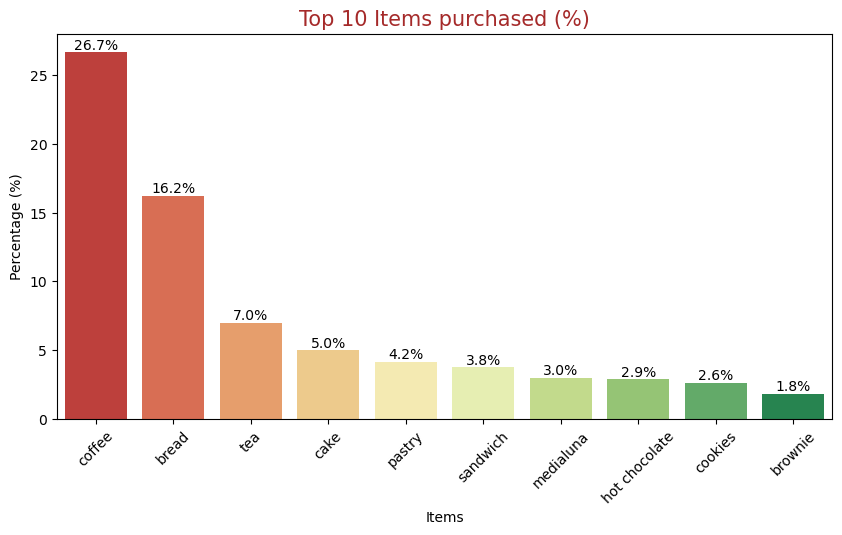

In [13]:
top_10_percentages = df.Item.value_counts(normalize=True).head(10) * 100

plt.figure(figsize=(10,5))
sns.barplot(x=top_10_percentages.index, y=top_10_percentages.values, palette='RdYlGn')

plt.xlabel('Items', size = 10)
plt.ylabel('Percentage (%)', size = 10) 
plt.xticks(rotation=45)
plt.title('Top 10 Items purchased (%)', color = 'Brown', size = 15)

for i, v in enumerate(top_10_percentages.values):
    plt.text(i, v, f"{v:.1f}%", ha='center', va='bottom', fontsize=10)

plt.show()

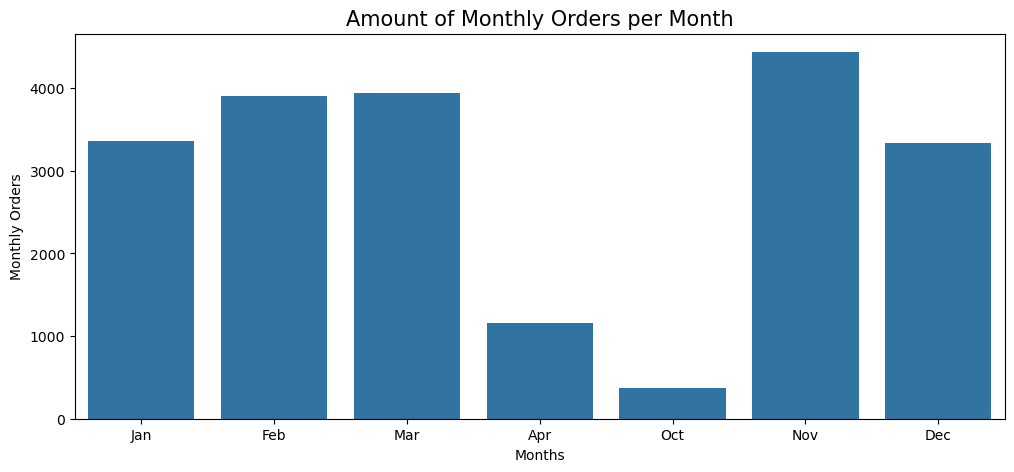

In [14]:
month_order = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}

mon_Tran =df.groupby('month')['Transaction'].count().reset_index()
mon_Tran.head(20)
mon_Tran['mon_order'] = mon_Tran['month'].map(month_order)
mon_Tran.sort_values("mon_order",inplace=True)

plt.figure(figsize=(12,5))
sns.barplot(data = mon_Tran, x = "month", y = "Transaction")
plt.xlabel('Months', size = 10)
plt.ylabel('Monthly Orders', size = 10)
plt.title('Amount of Monthly Orders per Month', color = 'black', size = 15)
plt.show()


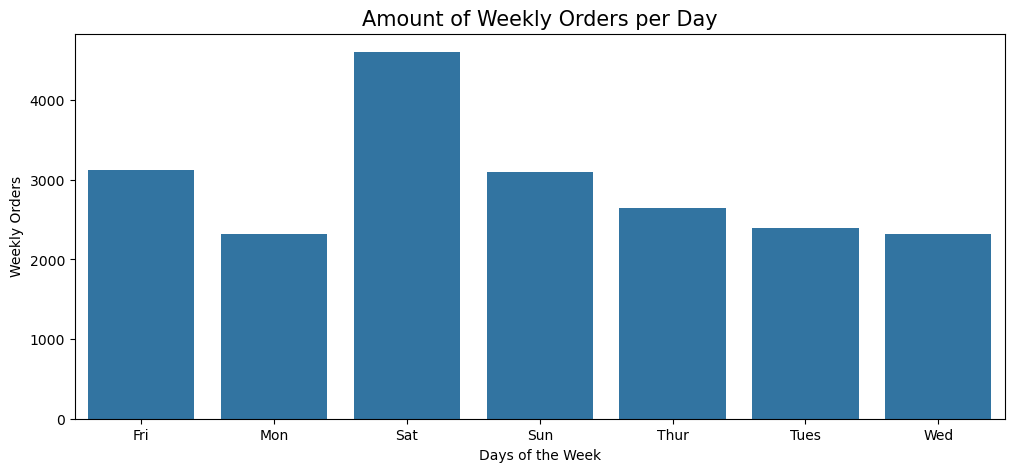

In [15]:
weekly_Tran =df.groupby('day_of_the_week')['Transaction'].count().reset_index()
weekly_Tran.head(20)
weekly_Tran['week_order'] = weekly_Tran['day_of_the_week']
weekly_Tran.sort_values("week_order",inplace=True)

plt.figure(figsize=(12,5))
sns.barplot(data = weekly_Tran, x = "day_of_the_week", y = "Transaction")
plt.xlabel('Days of the Week', size = 10)
plt.ylabel('Weekly Orders', size = 10)
plt.title('Amount of Weekly Orders per Day', color = 'black', size = 15)
plt.show()


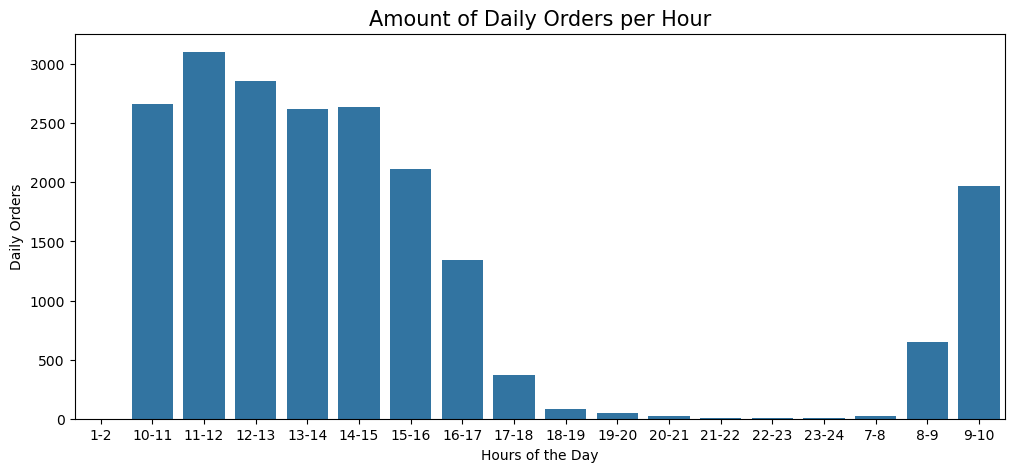

In [16]:
day_Tran =df.groupby('hour')['Transaction'].count().reset_index()
day_Tran.head(20)
day_Tran['hour_order'] = day_Tran['hour']
day_Tran.sort_values("hour",inplace=True)

plt.figure(figsize=(12,5))
sns.barplot(data = day_Tran, x = "hour", y = "Transaction")
plt.xlabel('Hours of the Day', size = 10)
plt.ylabel('Daily Orders', size = 10)
plt.title('Amount of Daily Orders per Hour', color = 'black', size = 15)
plt.show()


In [17]:
basket_sizes = df.groupby('Transaction')['Item'].count()

mean_basket_size = basket_sizes.mean()

percentage_1_to_3 = ((basket_sizes >= 1) & (basket_sizes <= 3)).mean() * 100


print(f"Mean Basket Size: {mean_basket_size:.1f} items")
print(f"Percentage of transactions with 1-3 items: {percentage_1_to_3:.1f}%")

Mean Basket Size: 2.2 items
Percentage of transactions with 1-3 items: 85.2%


In [18]:
top_20_items = df['Item'].value_counts().head(20).index.tolist()

target_item = 'scandinavian'
target_transactions = df[df['Item'] == target_item]['Transaction'].unique()


items_co_occurring_with_target = df[df['Transaction'].isin(target_transactions)]['Item'].unique()

overlap = set(top_20_items).intersection(set(items_co_occurring_with_target))

percentage = (len(overlap) / len(top_20_items)) * 100

print(f"Top 20 items: {top_20_items}")
print(f"Number of Top 20 items appearing with {target_item}: {len(overlap)}")
print(f"Co-occurrence percentage: {percentage}%")

Top 20 items: ['coffee', 'bread', 'tea', 'cake', 'pastry', 'sandwich', 'medialuna', 'hot chocolate', 'cookies', 'brownie', 'farm house', 'muffin', 'alfajores', 'juice', 'soup', 'scone', 'toast', 'scandinavian', 'truffles', 'coke']
Number of Top 20 items appearing with scandinavian: 19
Co-occurrence percentage: 95.0%


In [19]:
# One-hot encode
te = TransactionEncoder()
dataset = []

transactions_list = df.groupby('Transaction')['Item'].apply(list).values

transactions_np_array = te.fit_transform(transactions_list)

item_names = te.columns_

transactions_df = pd.DataFrame(transactions_np_array, columns=item_names)

transactions_df = transactions_df.astype(int)

print(transactions_df)

      adjustment  afternoon with the baker  alfajores  argentina night  \
0              0                         0          0                0   
1              0                         0          0                0   
2              0                         0          0                0   
3              0                         0          0                0   
4              0                         0          0                0   
...          ...                       ...        ...              ...   
9460           0                         0          0                0   
9461           0                         0          0                0   
9462           0                         0          0                0   
9463           0                         0          0                0   
9464           0                         0          0                0   

      art tray  bacon  baguette  bakewell  bare popcorn  basket  ...  \
0            0      0         0        

In [20]:
# --- MODIFIED SECTION ---
# Remove 'coffee' from dataset and reprocess
filtered_df = df[df['Item'] != 'coffee']

filtered_transactions_np_array = filtered_df.groupby('Transaction')['Item'].apply(list).values

filtered_transactions_df = te.fit_transform(filtered_transactions_np_array)

item_names = te.columns_

filtered_transactions_df = pd.DataFrame(filtered_transactions_df, columns=item_names)
filtered_transactions_df = filtered_transactions_df.astype(int)

print(filtered_transactions_df)

      adjustment  afternoon with the baker  alfajores  argentina night  \
0              0                         0          0                0   
1              0                         0          0                0   
2              0                         0          0                0   
3              0                         0          0                0   
4              0                         0          0                0   
...          ...                       ...        ...              ...   
8267           0                         0          0                0   
8268           0                         0          0                0   
8269           0                         0          0                0   
8270           0                         0          0                0   
8271           0                         0          0                0   

      art tray  bacon  baguette  bakewell  bare popcorn  basket  ...  \
0            0      0         0        

## Application of Apriori Algorithm

### With Coffee

In [21]:
frequent_items = apriori(transactions_df, min_support=0.02, use_colnames=True)
print("Frequent Itemsets:\n", frequent_items)

Frequent Itemsets:
      support                 itemsets
0   0.036344              (alfajores)
1   0.327205                  (bread)
2   0.040042                (brownie)
3   0.103856                   (cake)
4   0.478394                 (coffee)
5   0.054411                (cookies)
6   0.039197             (farm house)
7   0.058320          (hot chocolate)
8   0.038563                  (juice)
9   0.061807              (medialuna)
10  0.038457                 (muffin)
11  0.086107                 (pastry)
12  0.071844               (sandwich)
13  0.029054           (scandinavian)
14  0.034548                  (scone)
15  0.034443                   (soup)
16  0.142631                    (tea)
17  0.033597                  (toast)
18  0.020285               (truffles)
19  0.023349            (bread, cake)
20  0.090016          (bread, coffee)
21  0.029160          (bread, pastry)
22  0.028104             (bread, tea)
23  0.054728           (coffee, cake)
24  0.023772              (cak

In [22]:
# Step 2: Generate Rules
rules = association_rules(frequent_items, metric="lift", min_threshold=0.6)
print("\nAssociation Rules:\n", rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])


Association Rules:
         antecedents      consequents   support  confidence      lift
0           (bread)           (cake)  0.023349    0.071359  0.687097
1            (cake)          (bread)  0.023349    0.224822  0.687097
2           (bread)         (pastry)  0.029160    0.089119  1.034977
3          (pastry)          (bread)  0.029160    0.338650  1.034977
4           (bread)            (tea)  0.028104    0.085890  0.602181
5             (tea)          (bread)  0.028104    0.197037  0.602181
6          (coffee)           (cake)  0.054728    0.114399  1.101515
7            (cake)         (coffee)  0.054728    0.526958  1.101515
8            (cake)            (tea)  0.023772    0.228891  1.604781
9             (tea)           (cake)  0.023772    0.166667  1.604781
10         (coffee)        (cookies)  0.028209    0.058966  1.083723
11        (cookies)         (coffee)  0.028209    0.518447  1.083723
12         (coffee)  (hot chocolate)  0.029583    0.061837  1.060311
13  (hot choc

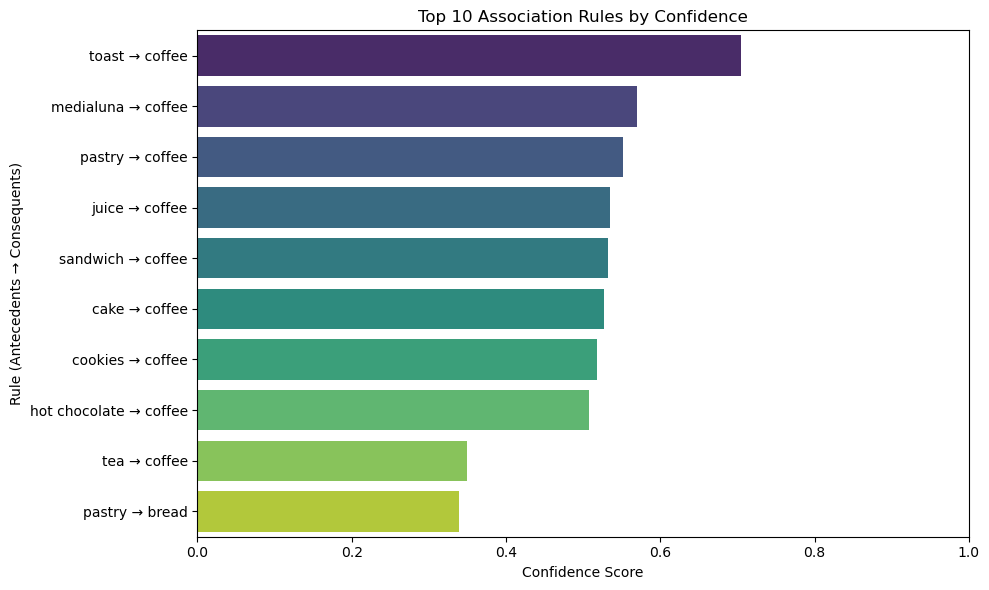

In [23]:
top_10_rules = rules.sort_values(by='confidence', ascending=False).head(10).copy()

top_10_rules['rule_name'] = top_10_rules.apply(
    lambda x: f"{', '.join(list(x['antecedents']))} \u2192 {', '.join(list(x['consequents']))}", 
    axis=1
)


plt.figure(figsize=(10, 6))
sns.barplot(x='confidence', y='rule_name', data=top_10_rules, palette='viridis')

plt.xlabel('Confidence Score')
plt.ylabel('Rule (Antecedents \u2192 Consequents)')
plt.title('Top 10 Association Rules by Confidence')
plt.xlim(0, 1.0) # Confidence ranges from 0 to 1
plt.tight_layout()
plt.show()

In [24]:
conf_rules = association_rules(frequent_items, metric="confidence", min_threshold=0.02)
sorted_rules = conf_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift', 'conviction','leverage']].sort_values(by='confidence', ascending=False)
print("Top Association Rules Sorted by Confidence:")
print(sorted_rules.head(10))

#Only uncomment if you want to export
# export_df = sorted_rules.head(10).copy()
# export_df['antecedents'] = export_df['antecedents'].apply(lambda x: ', '.join(list(x)))
# export_df['consequents'] = export_df['consequents'].apply(lambda x: ', '.join(list(x)))

# export_df.to_csv('top_association_rules_w_coffee.csv', index=False)

# print("Top Association Rules Sorted by Confidence:")
# print(export_df)
# print("\nFile 'top_association_rules_w_coffee.csv' has been saved successfully.")

Top Association Rules Sorted by Confidence:
        antecedents consequents   support  confidence      lift  conviction  \
26          (toast)    (coffee)  0.023666    0.704403  1.472431    1.764582   
18      (medialuna)    (coffee)  0.035182    0.569231  1.189878    1.210871   
21         (pastry)    (coffee)  0.047544    0.552147  1.154168    1.164682   
17          (juice)    (coffee)  0.020602    0.534247  1.116750    1.119919   
23       (sandwich)    (coffee)  0.038246    0.532353  1.112792    1.115384   
9            (cake)    (coffee)  0.054728    0.526958  1.101515    1.102664   
13        (cookies)    (coffee)  0.028209    0.518447  1.083723    1.083174   
15  (hot chocolate)    (coffee)  0.029583    0.507246  1.060311    1.058553   
25            (tea)    (coffee)  0.049868    0.349630  0.730840    0.802014   
5          (pastry)     (bread)  0.029160    0.338650  1.034977    1.017305   

    leverage  
26  0.007593  
18  0.005614  
21  0.006351  
17  0.002154  
23  0.00387

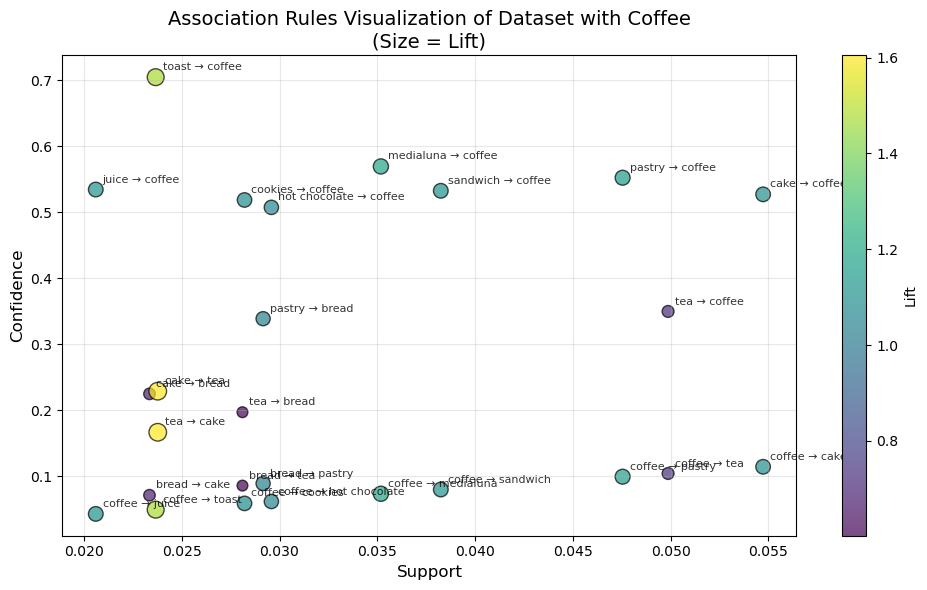

In [25]:
if len(rules) > 0:
    plt.figure(figsize=(10, 6))

    # Scatter plot: support vs confidence, sized by lift
    scatter = plt.scatter(
        rules['support'],
        rules['confidence'],
        s=rules['lift'] * 100,  # Size represents lift
        c=rules['lift'],        # Color represents lift
        cmap='viridis',
        edgecolors='k',
        alpha=0.7
    )

    # Add labels for each rule
    for idx, row in rules.iterrows():
        antecedents = ', '.join(list(row['antecedents']))
        consequents = ', '.join(list(row['consequents']))
        plt.annotate(
            f"{antecedents} → {consequents}",
            xy=(row['support'], row['confidence']),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=8,
            alpha=0.8
        )

    plt.xlabel('Support', fontsize=12)
    plt.ylabel('Confidence', fontsize=12)
    plt.title('Association Rules Visualization of Dataset with Coffee\n(Size = Lift)', fontsize=14)
    plt.colorbar(scatter, label='Lift')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No association rules found with the given thresholds.")

### Without Coffee

In [26]:
frequent_items = apriori(filtered_transactions_df, min_support=0.02, use_colnames=True)
print("Frequent Itemsets:\n", frequent_items)

Frequent Itemsets:
      support          itemsets
0   0.041586       (alfajores)
1   0.374396           (bread)
2   0.045817         (brownie)
3   0.118835            (cake)
4   0.022244            (coke)
5   0.062258         (cookies)
6   0.044850      (farm house)
7   0.066731   (hot chocolate)
8   0.044125           (juice)
9   0.070721       (medialuna)
10  0.044004          (muffin)
11  0.098525          (pastry)
12  0.082205        (sandwich)
13  0.033245    (scandinavian)
14  0.039531           (scone)
15  0.039410            (soup)
16  0.020793  (spanish brunch)
17  0.163201             (tea)
18  0.038443           (toast)
19  0.023211        (truffles)
20  0.026717     (bread, cake)
21  0.033366   (bread, pastry)
22  0.032157      (bread, tea)
23  0.027200       (cake, tea)


In [27]:
# Step 2: Generate Rules
rules = association_rules(frequent_items, metric="lift", min_threshold=0.02)
print("\nAssociation Rules:\n", rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])


Association Rules:
   antecedents consequents   support  confidence      lift
0     (bread)      (cake)  0.026717    0.071359  0.600493
1      (cake)     (bread)  0.026717    0.224822  0.600493
2     (bread)    (pastry)  0.033366    0.089119  0.904525
3    (pastry)     (bread)  0.033366    0.338650  0.904525
4     (bread)       (tea)  0.032157    0.085890  0.526280
5       (tea)     (bread)  0.032157    0.197037  0.526280
6      (cake)       (tea)  0.027200    0.228891  1.402509
7       (tea)      (cake)  0.027200    0.166667  1.402509


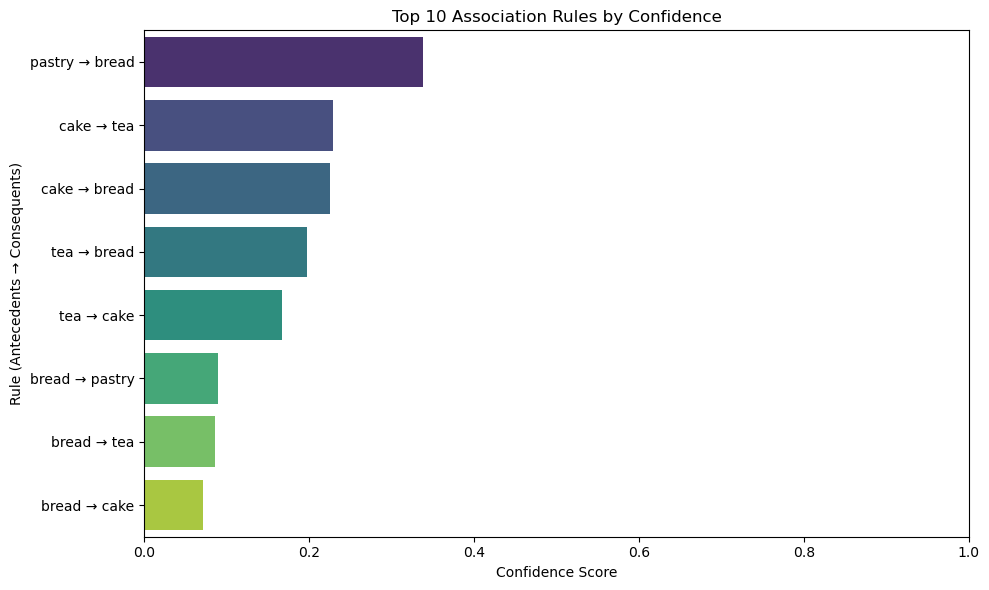

In [28]:
top_10_rules = rules.sort_values(by='confidence', ascending=False).head(10).copy()

top_10_rules['rule_name'] = top_10_rules.apply(
    lambda x: f"{', '.join(list(x['antecedents']))} \u2192 {', '.join(list(x['consequents']))}", 
    axis=1
)


plt.figure(figsize=(10, 6))
sns.barplot(x='confidence', y='rule_name', data=top_10_rules, palette='viridis')

plt.xlabel('Confidence Score')
plt.ylabel('Rule (Antecedents \u2192 Consequents)')
plt.title('Top 10 Association Rules by Confidence')
plt.xlim(0, 1.0) # Confidence ranges from 0 to 1
plt.tight_layout()
plt.show()

In [29]:
conf_rules = association_rules(frequent_items, metric="confidence", min_threshold=0.02)
sorted_rules = conf_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift', 'conviction','leverage']].sort_values(by='confidence', ascending=False)
print("Top Association Rules Sorted by Confidence:")
print(sorted_rules.head(10))

#Only uncomment if you want to export
# export_df = sorted_rules.head(10).copy()
# export_df['antecedents'] = export_df['antecedents'].apply(lambda x: ', '.join(list(x)))
# export_df['consequents'] = export_df['consequents'].apply(lambda x: ', '.join(list(x)))

# export_df.to_csv('top_association_rules_no_coffee.csv', index=False)

# print("Top Association Rules Sorted by Confidence:")
# print(export_df)
# print("\nFile 'top_association_rules_no_coffee.csv' has been saved successfully.")

Top Association Rules Sorted by Confidence:
  antecedents consequents   support  confidence      lift  conviction  \
3    (pastry)     (bread)  0.033366    0.338650  0.904525    0.945951   
6      (cake)       (tea)  0.027200    0.228891  1.402509    1.085189   
1      (cake)     (bread)  0.026717    0.224822  0.600493    0.807046   
5       (tea)     (bread)  0.032157    0.197037  0.526280    0.779120   
7       (tea)      (cake)  0.027200    0.166667  1.402509    1.057398   
2     (bread)    (pastry)  0.033366    0.089119  0.904525    0.989673   
4     (bread)       (tea)  0.032157    0.085890  0.526280    0.915424   
0     (bread)      (cake)  0.026717    0.071359  0.600493    0.948877   

   leverage  
3 -0.003522  
6  0.007806  
1 -0.017775  
5 -0.028945  
7  0.007806  
2 -0.003522  
4 -0.028945  
0 -0.017775  


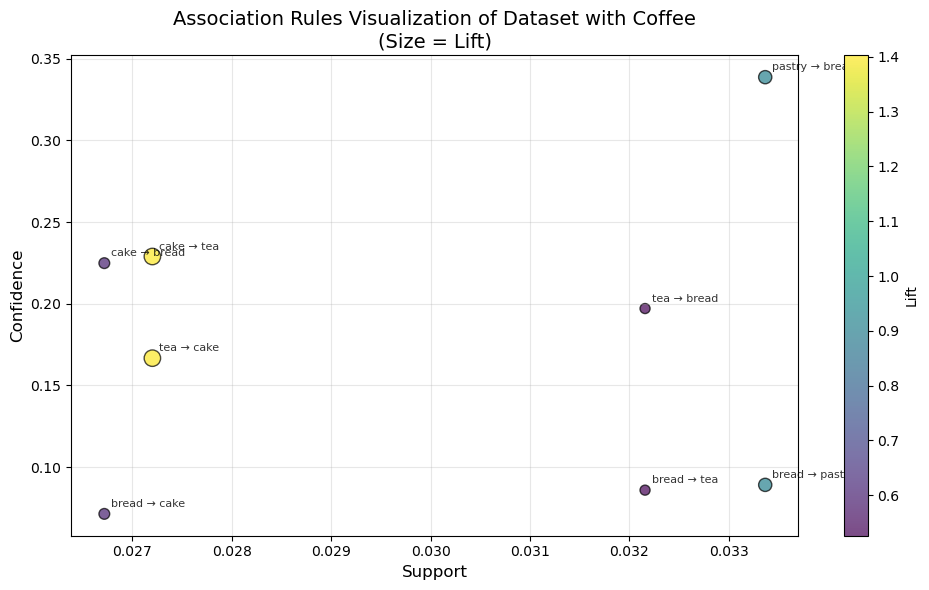

Total notebook runtime: 1.54 seconds


In [30]:
if len(rules) > 0:
    plt.figure(figsize=(10, 6))

    # Scatter plot: support vs confidence, sized by lift
    scatter = plt.scatter(
        rules['support'],
        rules['confidence'],
        s=rules['lift'] * 100,  # Size represents lift
        c=rules['lift'],        # Color represents lift
        cmap='viridis',
        edgecolors='k',
        alpha=0.7
    )

    # Add labels for each rule
    for idx, row in rules.iterrows():
        antecedents = ', '.join(list(row['antecedents']))
        consequents = ', '.join(list(row['consequents']))
        plt.annotate(
            f"{antecedents} → {consequents}",
            xy=(row['support'], row['confidence']),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=8,
            alpha=0.8
        )

    plt.xlabel('Support', fontsize=12)
    plt.ylabel('Confidence', fontsize=12)
    plt.title('Association Rules Visualization of Dataset with Coffee\n(Size = Lift)', fontsize=14)
    plt.colorbar(scatter, label='Lift')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No association rules found with the given thresholds.")

end_time = time.time()
total_runtime = end_time - start_time
print(f"Total notebook runtime: {total_runtime:.2f} seconds")